In [ ]:
import pandas as pd
from urllib.parse import urlparse


In [ ]:
df = pd.read_csv(
    "/content/benign_vs_defacement_urls.csv",encoding="latin-1",engine="python",on_bad_lines="skip")


In [ ]:
df.dropna()
df["url"] = df["url"].astype(str)


In [ ]:
SHORTENERS = [
    "bit.ly", "tinyurl", "goo.gl", "t.co", "ow.ly", "is.gd", "buff.ly", "adf.ly"
]

df["url_length"] = df["url"].apply(len)

df["hostname_length"] = df["url"].apply(
    lambda x: len(urlparse(x).netloc)
)

df["is_shortened"] = df["url"].apply(
    lambda x: int(any(s in urlparse(x).netloc for s in SHORTENERS))
)

df["digit_count"] = df["url"].apply(lambda x: sum(c.isdigit() for c in x))
df["slash_count"] = df["url"].apply(lambda x: x.count("/"))
df["dot_count"] = df["url"].apply(lambda x: x.count("."))
df["dash_count"] = df["url"].apply(lambda x: x.count("-"))
df["at_count"] = df["url"].apply(lambda x: x.count("@"))
df["question_count"] = df["url"].apply(lambda x: x.count("?"))
df["percent_count"] = df["url"].apply(lambda x: x.count("%"))
df["equal_count"] = df["url"].apply(lambda x: x.count("="))
df["label"] = df["type"].map({
    "benign": 0,
    "defacement": 1
})
df = df.dropna(subset=["label"])


In [ ]:
def length_of_url(url):
  return len(url)
def length_of_hostname(url):
  if url[:4]=="http":
    host_name = url[7:]
    return len(host_name.split('/')[0])
  elif url[:5]=="https":
    host_name = url[8:]
    return len(host_name.split('/')[0])
  else:
    return len(url.split('/')[0])

def count_of_symbols(url,symbol):# ., -, @, ?, %, =,
  return url.count(symbol)

def count_of_numbers(url):
  count_numbers = 0
  for i in url:
    if i.isdigit():
      count_numbers+=1
  return count_numbers

def count_of_dictionaries(url):
  if url[:4]=="http":
    host_name = url[7:]
    return len(host_name.split('/'))
  elif url[:5]=="https":
    host_name = url[8:]
    return len(host_name.split('/'))
  else:
    return len(url.split('/'))




In [ ]:
from sklearn.utils import resample

df_benign = df[df["type"] == "benign"]
df_deface = df[df["type"] == "defacement"]

if len(df_deface) == 0:
    print("Warning: No 'defacement' samples found.")
    df_balanced = df_benign.copy()
elif len(df_benign) == 0:
    print("Warning: No 'benign' samples found.")
    df_balanced = df_deface.copy()
else:
    df_benign_down = resample(
        df_benign,
        replace=False,
        n_samples=len(df_deface),
        random_state=42
    )
    df_balanced = pd.concat([df_benign_down, df_deface]).sample(frac=1, random_state=42)

In [ ]:

X_train = df_balanced.drop(columns=["url", "type", "label"])
y_train = df_balanced["label"]


X_test = df.drop(columns=["url", "type", "label"])
y_test = df["label"]


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9667341010363326


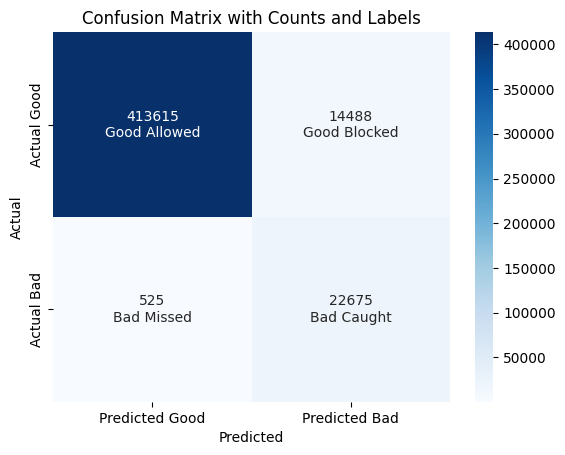

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm_labels = [
    ["Good Allowed", "Good Blocked"],
    ["Bad Missed", "Bad Caught"]
]

annot = [[f"{cm[i,j]}\n{cm_labels[i][j]}" for j in range(2)] for i in range(2)]

# Plot
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', xticklabels=["Predicted Good", "Predicted Bad"],
            yticklabels=["Actual Good", "Actual Bad"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix with Counts and Labels")
plt.show()


In [ ]:
def entropy(df):
  no_of_ones = (df['label'] == 1).sum()
  no_of_zeros = (df['label'] == 0).sum()
  total_no = len(df)

  entropy_one = -((no_of_ones/total_no)*np.log2(no_of_ones/total_no))
  entropy_zero = -((no_of_zeros/total_no)*np.log2(no_of_zeros/total_no))
  entropy = entropy_one + entropy_zero
  return entropy

In [ ]:
parents_entropy = entropy(df_balanced)
weighted_avg = (df_balanced['is_shortened'] == 1).sum()/len(df_balanced)*(entropy(df_balanced[df_balanced['is_shortened'] == 1])) + (df_balanced['is_shortened'] == 0).sum()/len(df_balanced)*(entropy(df_balanced[df_balanced['is_shortened'] == 0]))


0.9948522905120112
1.0
0.005147709487988816
